In [49]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "" 
os.environ["JAX_PLATFORMS"] = "cpu"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
from cosmographi.utils.perturbations import generate_perturbations_vector
import jax.numpy as jnp 
from cosmographi.source.agn import AGNSourceLipunova2018
from cosmographi.instrument.rubin import RubinObservatory
from scipy.optimize import minimize
import numpy as np
import cosmographi as cp
import jax
import matplotlib.pyplot as plt
from cosmographi.utils.constants import M_sun
jax.config.update("jax_enable_x64", True)

In [50]:
print(np.asarray([[1,2], [3,4]]))

[[1 2]
 [3 4]]


In [51]:
import numpy as np
import jax.numpy as jnp
import os
import jax

jax.config.update("jax_enable_x64", True)

os.environ["CUDA_VISIBLE_DEVICES"] = "" 
os.environ["JAX_PLATFORMS"] = "cpu"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
import matplotlib.pyplot as plt



def generate_perturbations_vector(alpha, n_samples, sample_rate=1.0, seed: int | None = None):
    """
    Generates 1D colored noise and plots the transformation steps.

    Parameters:
    alpha (float): The frequency scaling parameter (0=white, 1=pink, 2=brown).
    n_samples (int): Number of data points to generate.
    sample_rate (float): Assumed sample rate for frequency calculation.
    """
    rng = np.random.default_rng(seed=seed)
    white_noise = rng.normal(0, 1, n_samples)
    fft_white = jnp.fft.rfft(white_noise)
    frequencies = jnp.fft.rfftfreq(n_samples, d=1/sample_rate)
    # Ignore divide by zero for the DC component (f=0)
    with np.errstate(divide='ignore', invalid='ignore'):
        # Amplitude scales as 1/f^(alpha/2)
        scaling_factor = 1.0 / (frequencies ** (alpha / 2.0))
    scaling_factor = scaling_factor.at[0].set(0.0)
    fft_colored = fft_white * scaling_factor
    colored_noise = jnp.fft.irfft(fft_colored, n=n_samples)
    exp = jnp.exp(colored_noise)
    return exp / jnp.mean(exp)

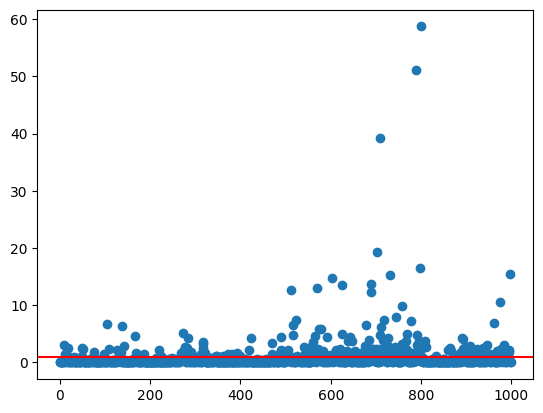

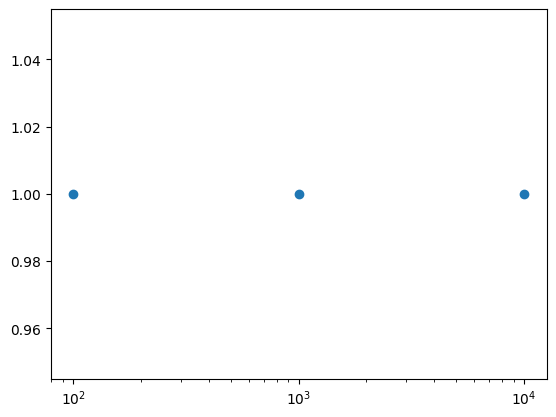

1.0
1.0
1.0
1.0
1.0
1.0
final mean: 1.0


In [52]:
plt.scatter(range(1000), generate_perturbations_vector(0.5, 1000))
plt.axhline(1, color="red")
plt.show()




sizes = [100, 1000, 10000]
alpha = 0.9

a = []
for size in sizes:
    avs = []
    for _ in range(1000):
        s = generate_perturbations_vector(alpha, size)
        avg = jnp.mean(s)
        if avg > 100:
            plt.plot(s)
            plt.show()
        avs.append(avg)
    a.append(avs)
a = np.asarray(a)
sa = np.mean(a[0])
sb = np.mean(a[1])
sc = np.mean(a[2])

plt.scatter(sizes, [sa, sb, sc])
plt.xscale("log")
plt.show()

print(sa)
print(np.median(a[0]))
print(sb)
print(np.median(a[1]))
print(sc)
print(np.median(a[2]))

print(f"final mean: {np.mean([sa, sb, sc])}")
# plt.scatter(sizes, a[:, 1])
# plt.xscale("log")
# plt.axhline(sb)
# plt.show()
# plt.scatter(sizes, a[:, 2])
# plt.xscale("log")
# plt.axhline(sc)
# plt.show()

# sepparation

In [53]:
from cosmographi.utils.constants import c_cm

def f_lambda_to_njy(model_flux, band, throughput):
    """
    Convert flux from F_lambda to nJy.

    Parameters
    ----------
    model_flux : array
        Flux from RubinObservatory.observe().
        Assumed units:
            erg / s / cm^2 / nm

    band : array
        Rubin band indices corresponding to each observation.

    throughput : Throughput object
        Rubin throughput object.

    Returns
    -------
    model_flux_njy : jax.Array
        Flux in nJy.
    """

    model_flux = jnp.asarray(model_flux).squeeze()
    band = np.asarray(band)
    # Collect effective wavelengths
    lambda_eff = []
    for b in band:
        # Full Rubin wavelength grid
        w = np.asarray(throughput.w[b])

        # Direct stored throughput array.
        # Avoid throughput.T(), which is caskade wrapped.
        T = np.asarray(throughput._T[b])

        # Throughput-weighted effective wavelength (nm)
        lam = np.trapezoid(w * T, w) / np.trapezoid(T, w)

        lambda_eff.append(lam)

    lambda_eff = jnp.asarray(lambda_eff)

    # nm -> cm
    lambda_cm = lambda_eff * 1e-7

    # F_lambda -> F_nu
    # F_nu = F_lambda * lambda^2 / c
    f_nu_cgs = model_flux * lambda_cm**2 / c_cm

    # erg/s/cm2/Hz -> nJy
    model_flux_njy = f_nu_cgs * 1e32

    return model_flux_njy

In [54]:
from cosmographi.utils.constants import c_nm
from cosmographi.utils.flux import f_nu

def compute_neg_log_likelihood(x: tuple[float], observed_flux: jnp.ndarray, times: jnp.ndarray, 
                           band: jnp.ndarray, exp_time: jnp.ndarray, sky_brightness: jnp.ndarray, PSF_Aeff: jnp.ndarray, 
                           blackhole_mass: float, accretion_rate: float, inclination_angle: float, rin_to_rng: float, z: float, noise_var = None) -> float: 
    """ Must pass with same format as Instrument.observe
    """
    start_time, end_time = (times[0], times[-1])
    if len(x) == 2:
        proposed_alpha, num_perturbation_samples = x
    else:
        proposed_alpha, num_perturbation_samples, noise_var = x
    num_perturbation_samples = max(int(round(num_perturbation_samples)), 2)
    sample_rate = num_perturbation_samples / (end_time - start_time)
    perturbations = generate_perturbations_vector(alpha=proposed_alpha, n_samples=num_perturbation_samples, sample_rate=sample_rate, seed=42)
    agn = AGNSourceLipunova2018(blackhole_mass=blackhole_mass, accretion_rate=accretion_rate, perturbations_ar=perturbations, 
                                start_time=start_time, end_time=end_time, rin_to_rng=rin_to_rng, inclination_angle=inclination_angle)
    rubin = RubinObservatory()
    rubin.throughput.trim()
    rubin.throughput.to_dynamic() 
    band, idx_to_bandstr = cp.utils.bandstr_to_bandidx(rubin.throughput.bands, band, return_dict=True)
    
    # flux = jnp.asarray(observed_flux)
    # correction = jnp.ones(flux.shape, dtype=flux.dtype)
    # bandstr_to_wavelength = {'u':360, 'g':475, 'r':620, 'i':755, 'z': 870, 'y': 985}
    # for i in np.unique(np.asarray(band)):
    #     bandstr = idx_to_bandstr[i]
    #     w = bandstr_to_wavelength[bandstr]
    #     correction = jnp.where(band == i, c_nm * 1e-15 / w**2, correction)
    # observed_flux = flux * correction
    


    key = jax.random.key(42)
    t_range = (jnp.min(times), jnp.max(times))
    source_t = np.random.uniform(*t_range)
    agn.t0 = source_t
    C = cp.cosmology.Cosmology()
    agn.z = z
    agn.cosmology = C
    agn.mu = agn.cosmology.distance_modulus(z)
    source_values = jnp.asarray(agn.get_values())
    survey_values = jnp.asarray(rubin.get_values())    
    obs = jax.vmap(rubin.observe, in_axes=(None, 0, 0, 0, 0, None, 0, None, None))
    model_flux = obs(key, band, exp_time, sky_brightness, PSF_Aeff, agn, times, source_values, survey_values)[0]
    w = rubin.throughput.w 
    model_flux_per_freq = f_nu(f_l=model_flux, w_l=w)
    model_flux_comparable_units = model_flux_per_freq * 1e32
    n = len(observed_flux)
    ll = (- n/2 * jnp.log(2*jnp.pi) - n/2 * jnp.log(noise_var) - 1/2/noise_var * jnp.sum((model_flux_comparable_units - observed_flux) ** 2)) * (-1)
    return float(ll)


def minimize_log_likelihood(observed_flux: jnp.ndarray, times: jnp.ndarray, band: jnp.ndarray, exp_time: jnp.ndarray, 
                            sky_brightness: jnp.ndarray, PSF_Aeff: jnp.ndarray, blackhole_mass: float, accretion_rate: float, 
                            inclination_angle: float, z: float, noise_var: float | None = None, rin_to_rng: float = 6) -> float:
    if noise_var is None:
        bounds = [(0.0, 2.0), (2.0, None), (1e-12, None)]
        args = (observed_flux, times, band, exp_time, sky_brightness, PSF_Aeff, blackhole_mass, accretion_rate, inclination_angle, rin_to_rng, z)
        x0 = np.asarray([0.88, (times[-1] - times[0])/ len(times), 3])
        results = minimize(compute_neg_log_likelihood, x0, args, method="Powell", bounds=bounds)
    else:
        bounds = [(0.0, 2.0), (2.0, None)]
        args = (observed_flux, times, band, exp_time, sky_brightness, PSF_Aeff, blackhole_mass, accretion_rate, inclination_angle, rin_to_rng, z, noise_var)
        x0 = np.asarray([0.88, (times[-1] - times[0])/ len(times)])
        results = minimize(compute_neg_log_likelihood, x0, args, method="Powell", bounds=bounds)
    return results


In [55]:
from astropy.cosmology import Planck18
from lightcurvelynx.astro_utils.passbands import PassbandGroup
from lightcurvelynx.astro_utils.redshift import RedshiftDistFunc
from lightcurvelynx.base_models import FunctionNode
from lightcurvelynx.math_nodes.np_random import NumpyRandomFunc
from lightcurvelynx.math_nodes.ra_dec_sampler import ObsTableRADECSampler
from lightcurvelynx.math_nodes.scipy_random import SamplePDF
from lightcurvelynx.models.agn import AGN
from lightcurvelynx.obstable.opsim import OpSim
from lightcurvelynx.simulate import simulate_lightcurves
from lightcurvelynx.survey_info import SurveyInfo
import pandas as pd

passband_group = PassbandGroup.from_preset(preset="LSST")
# It will take a while to download it. It took 9 min on Helen
obstable = OpSim.from_url(
    "https://s3df.slac.stanford.edu/data/rubin/sim-data/sims_featureScheduler_runs4.3/baseline/baseline_v4.3.5_10yrs.db",)


# Draw redshift from the uniform distribution
redshift = NumpyRandomFunc("uniform", low=0.1, high=1.0)
# Draw decimal logarithm of the black hole mass (in solar masses)
# from the uniform distribution
lg_bh_mass = NumpyRandomFunc("uniform", low=7.0, high=9.0)
# Transform to mass in solar masses
bh_mass = FunctionNode(
    lambda lg_mass: 10**lg_mass,
    lg_mass=lg_bh_mass,
    node_label="bh_mass",
)
# Eddington ratio for the accretion rate, e.g. accretion rate to critical value ratio
# First, we define a PDF function, for "blue" galaxies, see
# https://github.com/burke86/imbh_forecast/blob/master/var.ipynb
# https://ui.adsabs.harvard.edu/abs/2019ApJ...883..139S/abstract
# https://iopscience.iop.org/article/10.3847/1538-4357/aa803b/pdf
def edd_ratio_pdf(value):
    xi = 10**-1.65
    lambda_br = 10**-1.84
    delta1 = 0.471 - 0.7
    delta2 = 2.53
    min_lambda = 0.01
    max_lambda = 1.0
    value = np.asarray(value)
    fill_mask = (value >= min_lambda) & (value <= max_lambda)
    prob = np.zeros_like(value)
    prob[fill_mask] = xi / (
        (value[fill_mask] / lambda_br) ** delta1 + (value[fill_mask] / lambda_br) ** delta2
    )
    return prob

# We use a special random node to sample from this PDF
edd_ratio = SamplePDF(edd_ratio_pdf)
# We use a special distribution to draw positions from the survey coverage area
radec = ObsTableRADECSampler(
    obstable,
    radius=3.0,  # degrees
    node_label="ra_dec_sampler",
)

model = AGN(
    # Reference time is not important for a stochastic model
    t0=obstable.time_bounds()[0],  # reference date, the survey start
    blackhole_mass=bh_mass,  # black hole mass in solar masses
    edd_ratio=edd_ratio,  # accretion rate to critical accretion rate raio
    redshift=redshift,
    ra=radec.ra,
    dec=radec.dec,
    cosmology=Planck18,
    inclination=0
)

# Make it reproducible
rng = np.random.default_rng(42)

survey_info = SurveyInfo(obstable=obstable, passband_group=passband_group)

df = simulate_lightcurves(
    model=model,
    num_samples=10,
    survey_info=survey_info,
    param_cols=[
        "bh_mass.lg_mass",
        "AGN_0.edd_ratio",
    ],
    rng=rng,
)
# params is too large to show =)


Simulating: 100%|██████████| 10/10 [00:07<00:00,  1.38obj/s]


In [56]:
SECS_IN_YEAR = 31536000
data = jnp.asarray(df.loc[0, "lightcurve"][["mjd", "flux"]])

#TODO; jax them all up
lc = df.loc[0, "lightcurve"]
obs_idx = jnp.asarray(lc["obs_idx"])
obs_t = jnp.asarray(obstable["time"].iloc[obs_idx])
exp_times = jnp.asarray(obstable["exptime"].iloc[obs_idx])
sky_brightnesses = jnp.asarray(obstable["skybrightness"].iloc[obs_idx])
filters = obstable["filter"].iloc[obs_idx].to_numpy()
times = data[:, 0]
flux = data[:, 1]
bh_mass = 10**df.loc[0,'bh_mass_lg_mass'] * M_sun
edd_ratio = df.loc[0, 'AGN_0_edd_ratio']
redshift = df.loc[0, 'z']
critical_accretion_rate = 1.4e18 * (bh_mass / M_sun)
accretion_rate = edd_ratio * SECS_IN_YEAR * critical_accretion_rate /1000
pixel_scale = obstable.survey_values["pixel_scale"]
PSF_Aeffs = (obstable["psf_footprint"].iloc[obs_idx].to_numpy()* pixel_scale**2)
results = minimize_log_likelihood(observed_flux=flux, band=filters, inclination_angle=0, 
                                  times=times, exp_time=exp_times, 
                                  sky_brightness=sky_brightnesses, 
                                  PSF_Aeff=PSF_Aeffs, blackhole_mass = bh_mass, 
                                  accretion_rate=accretion_rate, z=redshift, noise_var=1)



TypeError: mul got incompatible shapes for broadcasting: (764, 1), (6, 2944).

In [ ]:
print(results)

 message: Optimization terminated successfully.
 success: True
  status: 0
     fun: 1.9730545591621734e+19
       x: [ 4.577e-01  4.806e+00]
     nit: 2
   direc: [[ 1.000e+00  0.000e+00]
           [ 0.000e+00  1.000e+00]]
    nfev: 76


In [ ]:
proposed_alpha, num_perturbation_samples =  4.577e-01, 4.806e+00
start_time, end_time = (times[0], times[-1])
num_perturbation_samples = max(int(round(num_perturbation_samples)), 2)
sample_rate = num_perturbation_samples / (end_time - start_time)
perturbations = generate_perturbations_vector(alpha=proposed_alpha, n_samples=num_perturbation_samples, sample_rate=sample_rate, seed=42)
agn = AGNSourceLipunova2018(blackhole_mass=bh_mass, accretion_rate=accretion_rate, perturbations_ar=perturbations, 
                                start_time=start_time, end_time=end_time, rin_to_rng=6, inclination_angle=0)
rubin = RubinObservatory()
# rubin.throughput.trim()
rubin.throughput.to_dynamic() 
band, idx_to_bandstr = cp.utils.bandstr_to_bandidx(rubin.throughput.bands, filters, return_dict=True)
key = jax.random.key(42)
t_range = (jnp.min(times), jnp.max(times))
agn.t0 = start_time
C = cp.cosmology.Cosmology()
agn.z = redshift
agn.cosmology = C
agn.mu = agn.cosmology.distance_modulus(redshift)
source_values = jnp.asarray(agn.get_values())
print(source_values)
survey_values = jnp.asarray(rubin.get_values())    
print(survey_values)
obs = jax.vmap(rubin.observe, in_axes=(None, 0, 0, 0, 0, None, 0, None, None))
model_flux = obs(key, band, exp_times, sky_brightnesses, PSF_Aeffs, agn, times, source_values, survey_values)[0]

[2.75174837e-01 4.08029639e+01 6.09800432e+04]
[1.2]


In [ ]:
print(model_flux)

print(rubin.throughput.w.shape)
print(rubin.throughput.bands)
print(np.unique(band))

[[ 9.49140536e-06]
 [ 1.16629754e-05]
 [ 1.71919537e-05]
 [ 1.16087700e-05]
 [ 7.17973694e-06]
 [ 2.43146927e-06]
 [-4.41237687e-06]
 [ 4.63255209e-06]
 [-6.69338775e-06]
 [-5.45150585e-06]
 [ 1.72930001e-05]
 [-2.73170558e-07]
 [-6.27215348e-06]
 [-8.13774185e-06]
 [ 8.69862530e-06]
 [ 3.58802927e-06]
 [-1.91343346e-06]
 [ 8.95266593e-06]
 [-7.20742335e-06]
 [-1.09974847e-05]
 [-1.30564777e-05]
 [-1.42139065e-05]
 [ 1.27141422e-05]
 [-1.21406382e-05]
 [ 8.07550458e-06]
 [-6.72526174e-06]
 [ 5.47495514e-06]
 [ 3.07965954e-06]
 [-1.21125024e-05]
 [-9.09166174e-06]
 [-7.73039247e-06]
 [ 8.20928318e-06]
 [ 8.48817417e-06]
 [-1.44011224e-05]
 [-1.16686880e-05]
 [ 9.86970904e-06]
 [-1.10358383e-05]
 [-2.28920666e-05]
 [-1.56281541e-05]
 [-2.98148832e-06]
 [ 3.90296977e-06]
 [ 7.21990367e-06]
 [-1.06056573e-05]
 [ 1.51228621e-05]
 [ 7.17557438e-06]
 [ 4.56150895e-06]
 [ 8.98785403e-06]
 [ 2.18746936e-06]
 [ 1.25788146e-05]
 [ 6.76509502e-06]
 [ 3.88500320e-06]
 [ 7.74455271e-07]
 [ 1.5287900

{'dynamic_params': (air_mass,),
 'pointer_params': (),
 'static_params': (),
 'dynamic_param_groups': (0,),
 '_name': 'Throughput_wAtmos',
 '_children': {'air_mass': air_mass},
 '_parents': {MagAB(MagAB), RubinObservatory(RubinObservatory)},
 '_subgraphs': set(),
 '_memos': set(),
 'node_type': 'module',
 'description': '',
 'meta': <caskade.base.meta at 0x7801d86b9c40>,
 'saveattrs': set(),
 '_valid_context': False,
 'bands': ['u', 'g', 'r', 'i', 'z', 'y'],
 '_w': Array([[ 300. ,  300.1,  300.2, ..., 1149.8, 1149.9, 1150. ],
        [ 300. ,  300.1,  300.2, ..., 1149.8, 1149.9, 1150. ],
        [ 300. ,  300.1,  300.2, ..., 1149.8, 1149.9, 1150. ],
        [ 300. ,  300.1,  300.2, ..., 1149.8, 1149.9, 1150. ],
        [ 300. ,  300.1,  300.2, ..., 1149.8, 1149.9, 1150. ],
        [ 300. ,  300.1,  300.2, ..., 1149.8, 1149.9, 1150. ]],      dtype=float64),
 '_T': Array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        

In [ ]:
# perturbations = generate_perturbations_vector(alpha=proposed_alpha, n_samples=num_perturbation_samples, seed=42)
# agn = AGNSourceLipunova2018(blackhole_mass=blackhole_mass, accretion_rate=accretion_rate, perturbations_ar=perturbations, 
#                                 start_time=start_time, end_time=end_time, rin_to_rng=rin_to_rng, inclination_angle=inclination_angle)
# rubin = RubinObservatory()
# rubin.throughput.trim()
# rubin.throughput.to_dynamic() 
# band, idx_to_bandstr = cp.utils.bandstr_to_bandidx(rubin.throughput.bands, band, return_dict=True)
# key = jax.random.key(42)
# t_range = (jnp.min(times), jnp.max(times))
# source_t = np.random.uniform(*t_range)
#     agn.t0 = source_t
#     C = cp.cosmology.Cosmology()
#     agn.z = z
#     agn.cosmology = C
#     agn.mu = agn.cosmology.distance_modulus(source_z)
#     source_values = jnp.asarray(agn.get_values())
#     survey_values = jnp.asarray(rubin.get_values())    
#     obs = jax.vmap(rubin.observe, in_axes=(None, 0, 0, 0, 0, None, 0, None, None))
#     model_flux = obs(key, band, exp_time, sky_brightness, PSF_Aeff, agn, times, source_values, survey_values)[0]

In [ ]:
print(df["AGN_0_edd_ratio"].describe())

count    10.000000
mean      0.023162
std       0.010993
min       0.010108
25%       0.013648
50%       0.022340
75%       0.029767
max       0.040020
Name: AGN_0_edd_ratio, dtype: float64


# Trying to make a DRW w/ Tiny GP

In [ ]:
from tinygp import GaussianProcess, kernels
import jax 
import jax.numpy as jnp
import matplotlib.pyplot as plt
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "" 
os.environ["JAX_PLATFORMS"] = "cpu"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"


def build_gp(theta: tuple[float], x: jnp.ndarray) -> GaussianProcess:
    """ Build a Gaussian Process with the given parameters and input data.
    Precondition: theta is a tuple of (log_sigma, log_scale, log_noise) parameters.
    """
    log_sigma, log_scale, log_noise = theta
    kernel = kernels.stationary.Exp(scale=jnp.exp(log_scale), sigma=jnp.exp(log_sigma))
    return GaussianProcess(kernel, x, diag=jnp.exp(log_noise)**2)



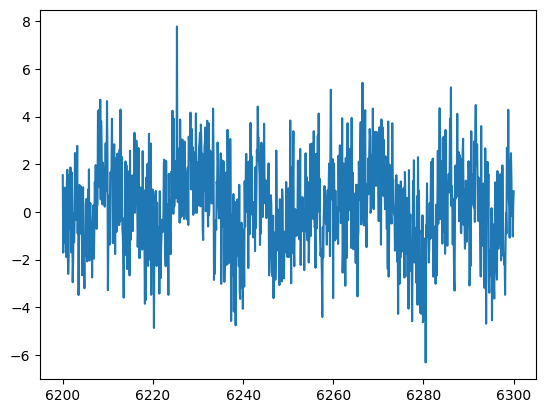

In [ ]:
scale = 1.0
noise = 0.5

theta = (scale, noise)

x = jnp.linspace(6200, 6300, 1000)

log_scale, log_noise = theta
kernel = kernels.stationary.Exp(scale=jnp.exp(log_scale))
gp = GaussianProcess(kernel, x, diag=jnp.exp(log_noise)**2)

key = jax.random.key(42)

samples = gp.sample(key)

plt.plot(x, samples)
plt.show()

In [ ]:
import jax.numpy as jnp

diag = jnp.exp(log_noise)**2

print("diag:", diag)
print("finite:", jnp.isfinite(diag))

K = kernel(x, x)
print("K finite:", jnp.all(jnp.isfinite(K)))
print("diag(K):", K.diagonal()[:5])

C = K + diag * jnp.eye(len(x))

print("C finite:", jnp.all(jnp.isfinite(C)))


print(theta)
print(jnp.exp(log_scale))
print(jnp.exp(log_noise))

diag: 2.7182818284590455
finite: True


K finite: True
diag(K): [1. 1. 1. 1. 1.]
C finite: True
(1.0, 0.5)
2.718281828459045
1.6487212707001282


In [ ]:
from jax.scipy.linalg import cholesky

L = cholesky(C, lower=True)
print(L.shape)

(1000, 1000)
